# DESCRIPTION

analysis of GPCR15 experiments 

## Receptor simulations

### RL_complex run1

In [1]:
%cd /mnt/d/PhD/GPCR15/receptor/run1/rl_complex

/mnt/d/PhD/GPCR15/receptor/run1/rl_complex


In [8]:
#!echo "CENTER SOLU_MEMB" | gmx trjconv -f md.xtc -s md.tpr -pbc atom -center  -o md_pbc.xtc -n index.ndx
#!echo "MEMB SOLU_MEMB" | gmx trjconv -f md_pbc.xtc  -s md.tpr -pbc mol -center -o md_mol.xtc -n index.ndx
#!echo "SOLU_MEMB" | gmx trjconv -s md.tpr -f md_mol.xtc -o md_extract.gro -dump 289691 -n index.ndx

               :-) GROMACS - gmx trjconv, 2024.5-conda_forge (-:

Executable:   /home/davidelu/mambaforge/bin.AVX2_256/gmx
Data prefix:  /home/davidelu/mambaforge
Working dir:  /mnt/d/PhD/GPCR15/receptor/run1/rl_complex
Command line:
  gmx trjconv -f md.xtc -s md.tpr -pbc atom -center -o md_pbc.xtc -n index.ndx

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file md.tpr, VERSION 2025.2 (single precision)
Reading file md.tpr, VERSION 2025.2 (single precision)

-------------------------------------------------------
Program:     gmx trjconv, version 2024.5-conda_forge
Source file: listoflists.h (line 98)
Function:    gmx::ListOfLists< <template-parameter-1-1> >::ListOfLists(std::vector<int>&&, std::vector<T>&&) [with T = int]

Inconsistency in user input:
listRanges does not have a first element with value 0

For more information and tips for troubleshooting, please chec

In [14]:
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/RL_complex/solv_ions.gro   .

solv_ions.gro                                 100% 7256KB   6.4MB/s   00:01    


I had to transform the coordinates in nmrbox because the gromacs version used is 2025

In [3]:
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/RL_complex/md_mol.xtc .
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/RL_complex/md_extract.gro  .

md_mol.xtc                                    100%  550MB  13.1MB/s   00:42    
md_extract.gro                                100% 1730KB   2.2MB/s   00:00    


#### Analysis 

In [1]:
%cd /mnt/d/PhD/GPCR15/receptor/run1/rl_complex

/mnt/d/PhD/GPCR15/receptor/run1/rl_complex


In [2]:
import MDAnalysis as mda
import numpy as np
import pandas as pd
from MDAnalysis.analysis import align
import matplotlib.pyplot as plt
import seaborn as sns
from MDAnalysis.analysis.distances import distance_array
from matplotlib import gridspec
from MDAnalysis.analysis.rms import rmsd

/home/davidelu/mambaforge/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [4]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:348: UserWarning: Unknown element P3 found for some atoms. These have been given an empty element record. If needed they can be guessed using MDAnalysis.topology.guessers.
  warnings.warn(wmsg)
/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:373: UserWarning: Unknown entry 1 encountered in formal charge field. This likely indicates that the PDB file is not fully standard compliant. The formalcharges attribute will not be populated.
  warnings.warn(wmsg)
/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: P3
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))


In [5]:
receptor = u.select_atoms("chainID A and name CA")
ligand = u.select_atoms("resid 300-307 320-325 and chainID B and  name CA")

In [6]:
print(len(receptor), "CA receptor")
print(len(ligand), "CA ligand")

287 CA receptor
14 CA ligand


In [7]:
ref = mda.Universe("ref_vis.pdb")
aligner = align.AlignTraj(u, ref, select="chainID A and name CA", in_memory=True)
aligner.run()

In [8]:
data = []

for ts in u.trajectory:
    
    com_rec = receptor.center_of_mass()
    com_lig = ligand.center_of_mass()
    
    d = com_lig - com_rec
    
    dx, dy, dz = d
    
    r_xy = np.sqrt(dx**2 + dy**2)
    phi = np.arctan2(dy, dx)  # radianti
    
    data.append([ts.time, r_xy, phi, dz])

In [9]:
df = pd.DataFrame(data, columns=["time_ps", "r_xy", "phi_rad", "z"])

In [10]:
df["phi_deg"] = np.degrees(df["phi_rad"])
df.head()

,time_ps,r_xy,phi_rad,z,phi_deg
0,0.0,6.777515,1.258068,-61.878294,72.082010
1,100.0,6.744008,1.538430,-61.245353,88.145526
2,200.0,5.744825,0.846504,-58.879262,48.501116
3,300.0,3.407765,-1.260140,-58.059782,-72.200686
4,400.0,2.065312,0.125709,-59.333728,7.202612


/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


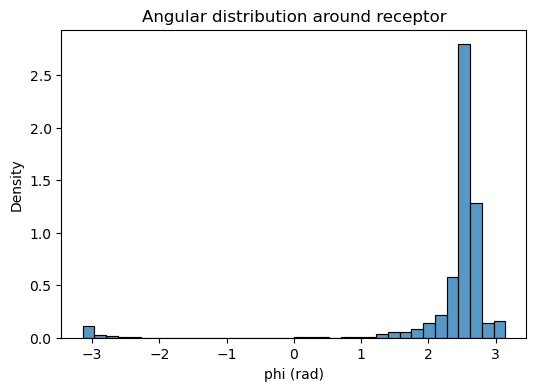

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["phi_rad"], bins=36, stat="density")
plt.xlabel("phi (rad)")
plt.ylabel("Density")
plt.title("Angular distribution around receptor")
plt.show()

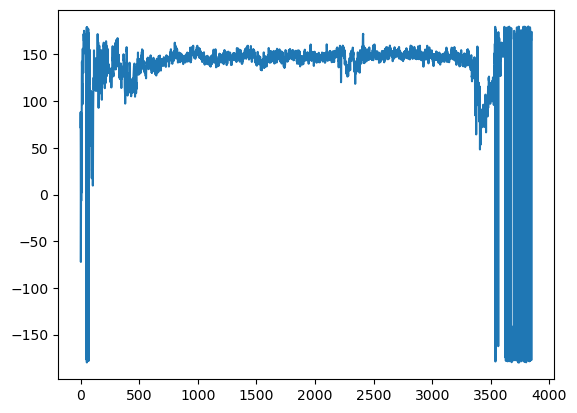

In [12]:
plt.plot(df["phi_deg"])

In [13]:
atom1 = u.select_atoms("id 2372")[0]
atom2 = u.select_atoms("id 5224")[0]

In [14]:
distances = []

for ts in u.trajectory:
    d = distance_array(atom1.position.reshape(1,3),
                       atom2.position.reshape(1,3),
                       box=u.dimensions)[0,0]
    distances.append(d)

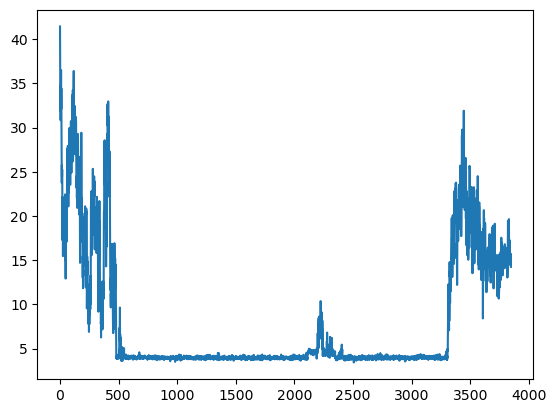

In [15]:
plt.plot(distances)

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'aspect'
  cset = contour_func(
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_

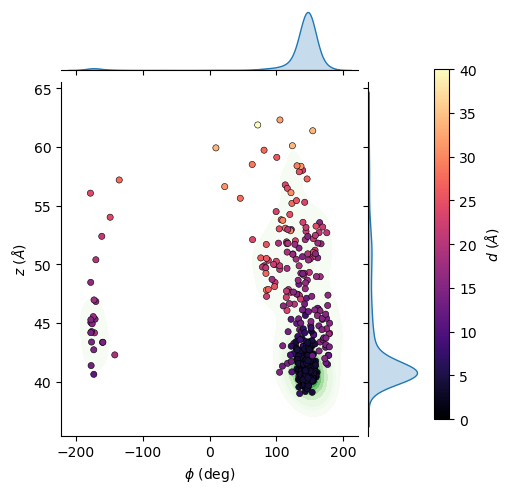

In [16]:
df["z_inv"] = -df["z"]

g = sns.jointplot(
    data=df,
    x='phi_deg',
    y='z_inv',
    kind="kde",
    fill=True,
    cmap="Greens",
    alpha=1,
    height=5,      # Altezza complessiva in pollici
    aspect=1.0     # Rapporto width/height
)


vmin, vmax = 0.0, 40

scatter = g.ax_joint.scatter(
    df['phi_deg'][::5],
    df['z_inv'][::5],
    c=distances[::5],
    cmap='magma',
    edgecolor='k',
    s=20,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.4
)


g.fig.subplots_adjust(right=0.85)

cbar_ax = g.fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label("$d~(\AA)$")

g.set_axis_labels(r"$\phi~(\deg)$",r"$z~(\AA)$")

plt.show()

#### RMSD

In [3]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")
ref = mda.Universe("../../../receptor_cryoEM.pdb")

/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:348: UserWarning: Unknown element P3 found for some atoms. These have been given an empty element record. If needed they can be guessed using MDAnalysis.topology.guessers.
  warnings.warn(wmsg)
/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:373: UserWarning: Unknown entry 1 encountered in formal charge field. This likely indicates that the PDB file is not fully standard compliant. The formalcharges attribute will not be populated.
  warnings.warn(wmsg)
/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/topology/guessers.py:146: UserWarning: Failed to guess the mass for the following atom types: P3
  warnings.warn("Failed to guess the mass for the following atom types: {}".format(atom_type))
/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:451: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. U

In [4]:
ref.select_atoms('chainID A and name CA')

<AtomGroup with 287 atoms>

In [5]:
aligner = align.AlignTraj(
    u,ref,
    select = "chainID A and name CA",
    in_memory=True
)
aligner.run()

In [6]:
mobile_frag = u.select_atoms("name CA and resid 338-344")
ref_frag    = ref.select_atoms("chainID L and name CA and resid 51-57")

print("mobile:", len(mobile_frag), "ref:", len(ref_frag))

mobile: 7 ref: 7


In [7]:
rmsd_all_rep1 = []
for ts in u.trajectory:
    r = rmsd(u.select_atoms('name CA and resid 338-344').positions, ref.select_atoms('chainID L and name CA and resid 51-57').positions)    
    rmsd_all_rep1.append(r)

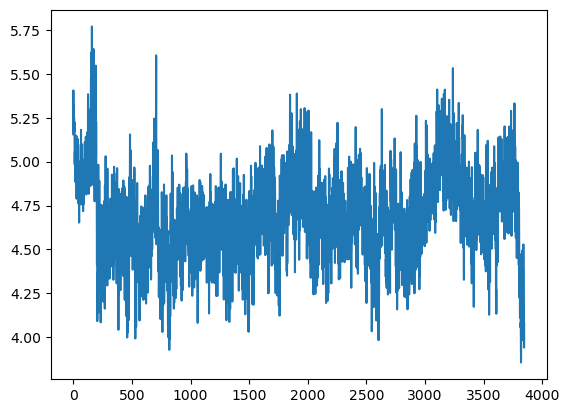

In [8]:
plt.plot(rmsd_all_rep1)

In [9]:
np.savetxt("rmsd_rep1.txt", rmsd_all_rep1)

### RL_complex run2

In [56]:
%cd /mnt/d/PhD/GPCR15/receptor/run2/rl_complex

/mnt/d/PhD/GPCR15/receptor/run2/rl_complex


In [54]:
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run2/RL_complex/md_mol.xtc .
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run2/RL_complex/md_extract.gro  .

md_mol.xtc                                    100%  429MB   5.4MB/s   01:19    
md_extract.gro                                100% 1730KB   2.1MB/s   00:00    


#### Analysis 

In [10]:
%cd /mnt/d/PhD/GPCR15/receptor/run2/rl_complex

/mnt/d/PhD/GPCR15/receptor/run2/rl_complex


In [11]:
import MDAnalysis as mda
import numpy as np
import pandas as pd
from MDAnalysis.analysis import align
import matplotlib.pyplot as plt
import seaborn as sns
from MDAnalysis.analysis.distances import distance_array
from matplotlib import gridspec

In [27]:
u = mda.Universe("../../run1/rl_complex/ref_vis.pdb", "md_mol.xtc")

In [28]:
receptor = u.select_atoms("chainID A and name CA")
ligand = u.select_atoms("resid 300-307 320-325 and chainID B and  name CA")

In [29]:
print(len(receptor), "CA receptor")
print(len(ligand), "CA ligand")

287 CA receptor
14 CA ligand


In [30]:
ref = mda.Universe("../../run1/rl_complex/ref_vis.pdb")
aligner = align.AlignTraj(u, ref, select="chainID A and name CA", in_memory=True)
aligner.run()

In [31]:
data = []

for ts in u.trajectory:
    
    com_rec = receptor.center_of_mass()
    com_lig = ligand.center_of_mass()
    
    d = com_lig - com_rec
    
    dx, dy, dz = d
    
    r_xy = np.sqrt(dx**2 + dy**2)
    phi = np.arctan2(dy, dx)  # radianti
    
    data.append([ts.time, r_xy, phi, dz])

In [32]:
df = pd.DataFrame(data, columns=["time_ps", "r_xy", "phi_rad", "z"])

In [33]:
df["phi_deg"] = np.degrees(df["phi_rad"])
df.head()

,time_ps,r_xy,phi_rad,z,phi_deg
0,0.0,4.930513,2.047365,-61.173284,117.305379
1,100.0,3.098066,2.349133,-60.479510,134.595399
2,200.0,8.081481,2.134154,-61.335891,122.278001
3,300.0,11.893636,1.977307,-58.754440,113.291366
4,400.0,11.840360,1.814743,-59.280337,103.977138


/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


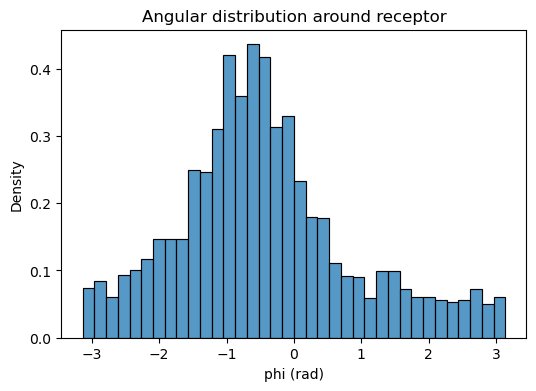

In [34]:
plt.figure(figsize=(6,4))
sns.histplot(df["phi_rad"], bins=36, stat="density")
plt.xlabel("phi (rad)")
plt.ylabel("Density")
plt.title("Angular distribution around receptor")
plt.show()

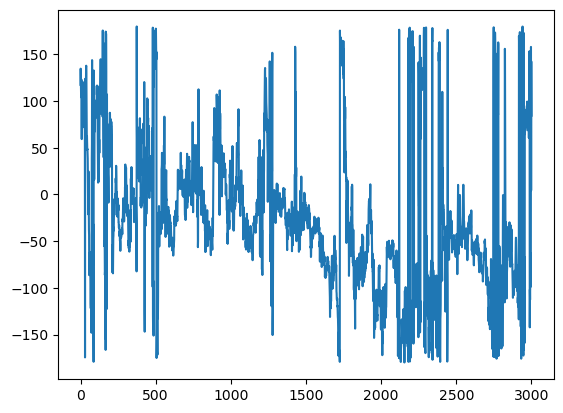

In [35]:
plt.plot(df["phi_deg"])

In [36]:
atom1 = u.select_atoms("id 2372")[0]
atom2 = u.select_atoms("id 5224")[0]

In [37]:
distances = []

for ts in u.trajectory:
    d = distance_array(atom1.position.reshape(1,3),
                       atom2.position.reshape(1,3),
                       box=u.dimensions)[0,0]
    distances.append(d)

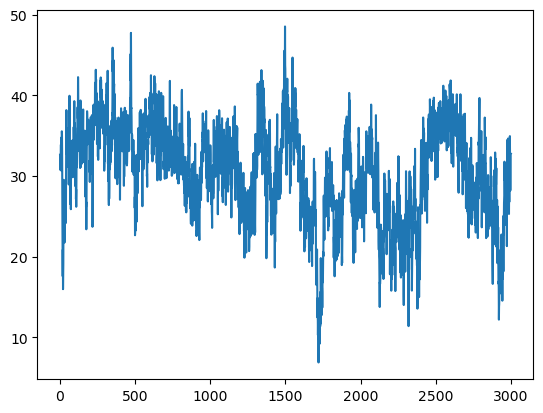

In [38]:
plt.plot(distances)

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'aspect'
  cset = contour_func(
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_

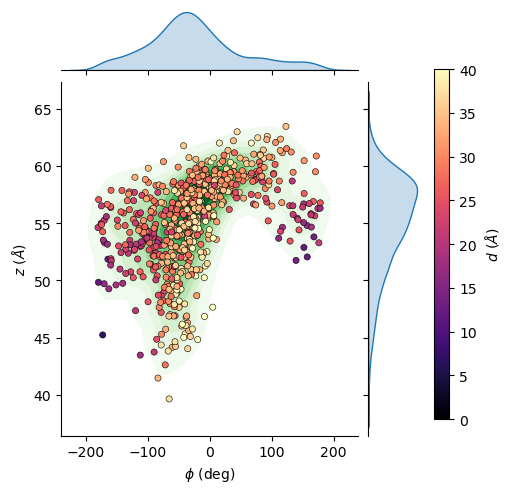

In [39]:
df["z_inv"] = -df["z"]

g = sns.jointplot(
    data=df,
    x='phi_deg',
    y='z_inv',
    kind="kde",
    fill=True,
    cmap="Greens",
    alpha=1,
    height=5,      # Altezza complessiva in pollici
    aspect=1.0     # Rapporto width/height
)


vmin, vmax = 0.0, 40

scatter = g.ax_joint.scatter(
    df['phi_deg'][::5],
    df['z_inv'][::5],
    c=distances[::5],
    cmap='magma',
    edgecolor='k',
    s=20,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.4
)


g.fig.subplots_adjust(right=0.85)

cbar_ax = g.fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label("$d~(\AA)$")

g.set_axis_labels(r"$\phi~(\deg)$",r"$z~(\AA)$")

plt.show()

#### RMSD

In [12]:
u = mda.Universe("../../run1/rl_complex/ref_vis.pdb", "md_mol.xtc")
ref = mda.Universe("../../../receptor_cryoEM.pdb")

In [13]:
ref.select_atoms('chainID A and name CA')

<AtomGroup with 287 atoms>

In [14]:
aligner = align.AlignTraj(
    u,ref,
    select = "chainID A and name CA",
    in_memory=True
)
aligner.run()

In [15]:
mobile_frag = u.select_atoms("name CA and resid 338-344")
ref_frag    = ref.select_atoms("chainID L and name CA and resid 51-57")

print("mobile:", len(mobile_frag), "ref:", len(ref_frag))

mobile: 7 ref: 7


In [16]:
rmsd_all_rep2 = []
for ts in u.trajectory:
    r = rmsd(u.select_atoms('name CA and resid 338-344').positions, ref.select_atoms('chainID L and name CA and resid 51-57').positions)    
    rmsd_all_rep2.append(r)

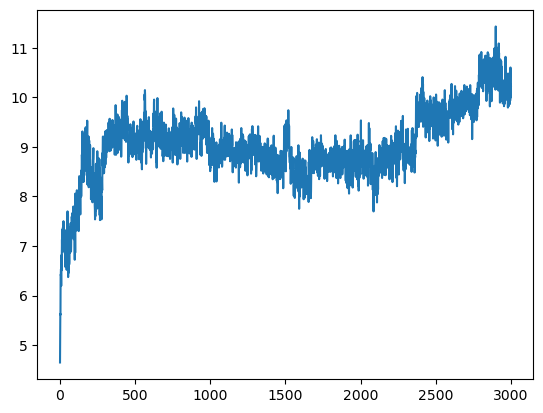

In [17]:
plt.plot(rmsd_all_rep2)

In [18]:
np.savetxt("rmsd_rep2.txt", rmsd_all_rep2)

### RL_complex run3

In [46]:
%cd /mnt/d/PhD/GPCR15/receptor/run3/rl_complex

/mnt/d/PhD/GPCR15/receptor/run3/rl_complex


In [ ]:
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run3/RL_complex/md_mol.xtc .
#!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run3/RL_complex/md_extract.gro  .

#### Analysis 

In [19]:
%cd /mnt/d/PhD/GPCR15/receptor/run3/rl_complex

/mnt/d/PhD/GPCR15/receptor/run3/rl_complex


In [20]:
import MDAnalysis as mda
import numpy as np
import pandas as pd
from MDAnalysis.analysis import align
import matplotlib.pyplot as plt
import seaborn as sns
from MDAnalysis.analysis.distances import distance_array

In [49]:
u = mda.Universe("../../run1/rl_complex/ref_vis.pdb", "md_mol.xtc")

/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:241: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn("Reload offsets from trajectory\n "


In [50]:
receptor = u.select_atoms("chainID A and name CA")
ligand = u.select_atoms("resid 300-307 320-325 and chainID B and  name CA")

In [51]:
print(len(receptor), "CA receptor")
print(len(ligand), "CA ligand")

287 CA receptor
14 CA ligand


In [52]:
ref = mda.Universe("../../run1/rl_complex/ref_vis.pdb")
aligner = align.AlignTraj(u, ref, select="chainID A and name CA", in_memory=True)
aligner.run()

In [53]:
data = []

for ts in u.trajectory:
    
    com_rec = receptor.center_of_mass()
    com_lig = ligand.center_of_mass()
    
    d = com_lig - com_rec
    
    dx, dy, dz = d
    
    r_xy = np.sqrt(dx**2 + dy**2)
    phi = np.arctan2(dy, dx)  # radianti
    
    data.append([ts.time, r_xy, phi, dz])

In [54]:
df = pd.DataFrame(data, columns=["time_ps", "r_xy", "phi_rad", "z"])

In [55]:
df["phi_deg"] = np.degrees(df["phi_rad"])
df.head()

,time_ps,r_xy,phi_rad,z,phi_deg
0,0.0,20.440250,2.558461,-53.583306,146.589029
1,100.0,19.769913,2.398663,-51.953044,137.433284
2,200.0,18.256007,1.986285,-53.221588,113.805770
3,300.0,18.174952,2.006516,-53.186678,114.964924
4,400.0,18.973756,1.789094,-48.765583,102.507516


/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


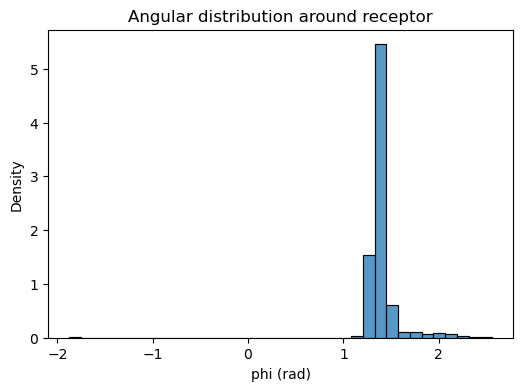

In [56]:
plt.figure(figsize=(6,4))
sns.histplot(df["phi_rad"], bins=36, stat="density")
plt.xlabel("phi (rad)")
plt.ylabel("Density")
plt.title("Angular distribution around receptor")
plt.show()

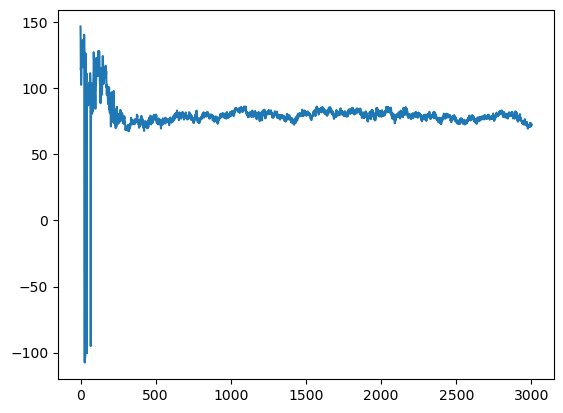

In [57]:
plt.plot(df["phi_deg"])

In [58]:
atom1 = u.select_atoms("id 2372")[0]
atom2 = u.select_atoms("id 5224")[0]

In [59]:
distances = []

for ts in u.trajectory:
    d = distance_array(atom1.position.reshape(1,3),
                       atom2.position.reshape(1,3),
                       box=u.dimensions)[0,0]
    distances.append(d)

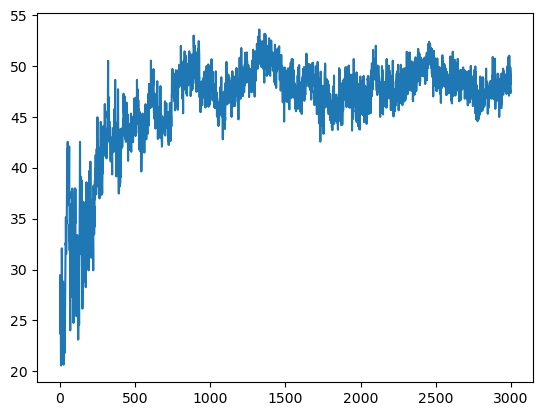

In [60]:
plt.plot(distances)

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/distributions.py:1185: UserWarning: The following kwargs were not used by contour: 'aspect'
  cset = contour_func(
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_

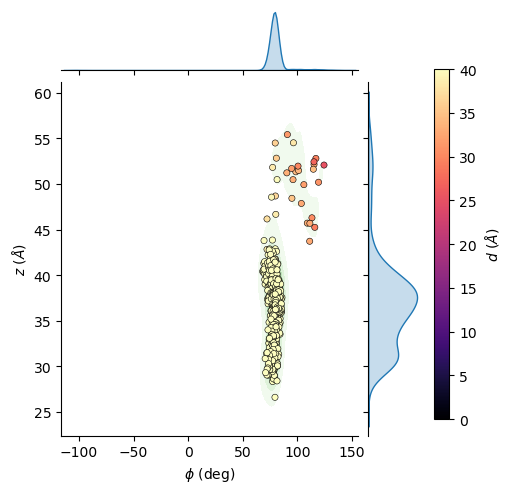

In [61]:
df["z_inv"] = -df["z"]

g = sns.jointplot(
    data=df,
    x='phi_deg',
    y='z_inv',
    kind="kde",
    fill=True,
    cmap="Greens",
    alpha=1,
    height=5,      # Altezza complessiva in pollici
    aspect=1.0     # Rapporto width/height
)


vmin, vmax = 0.0, 40

scatter = g.ax_joint.scatter(
    df['phi_deg'][100:][::5],
    df['z_inv'][100:][::5],
    c=distances[100:][::5],
    cmap='magma',
    edgecolor='k',
    s=20,
    vmin=vmin,
    vmax=vmax,
    linewidth=0.4
)


g.fig.subplots_adjust(right=0.85)

cbar_ax = g.fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label("$d~(\AA)$")

g.set_axis_labels(r"$\phi~(\deg)$",r"$z~(\AA)$")

plt.show()

#### RMSD

In [21]:
u = mda.Universe("../../run1/rl_complex/ref_vis.pdb", "md_mol.xtc")
ref = mda.Universe("../../../receptor_cryoEM.pdb")

In [22]:
ref.select_atoms('chainID A and name CA')

<AtomGroup with 287 atoms>

In [23]:
aligner = align.AlignTraj(
    u,ref,
    select = "chainID A and name CA",
    in_memory=True
)
aligner.run()

In [24]:
mobile_frag = u.select_atoms("name CA and resid 338-344")
ref_frag    = ref.select_atoms("chainID L and name CA and resid 51-57")

print("mobile:", len(mobile_frag), "ref:", len(ref_frag))

mobile: 7 ref: 7


In [25]:
rmsd_all = []
for ts in u.trajectory:
    r = rmsd(u.select_atoms('name CA and resid 338-344').positions, ref.select_atoms('chainID L and name CA and resid 51-57').positions)    
    rmsd_all.append(r)

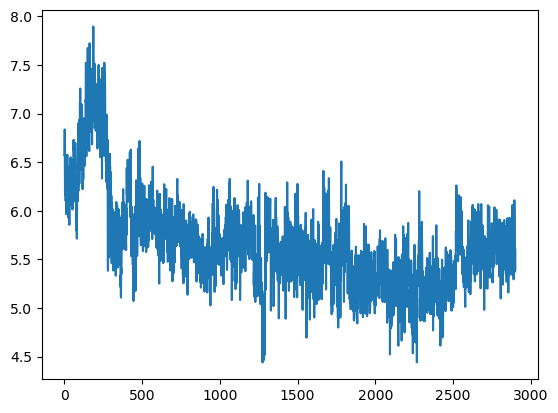

In [26]:
plt.plot(rmsd_all[100:])

In [27]:
rmsd_all_rep3= rmsd_all[100:]

In [28]:
np.savetxt("rmsd_rep3.txt", rmsd_all_rep3)

### RMSD comparison

In [ ]:
#rmsd_all_rep1 = np.loadtxt('')
#rmsd_all_rep2
#rmsd_all_rep3

/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/davidelu/mambaforge/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


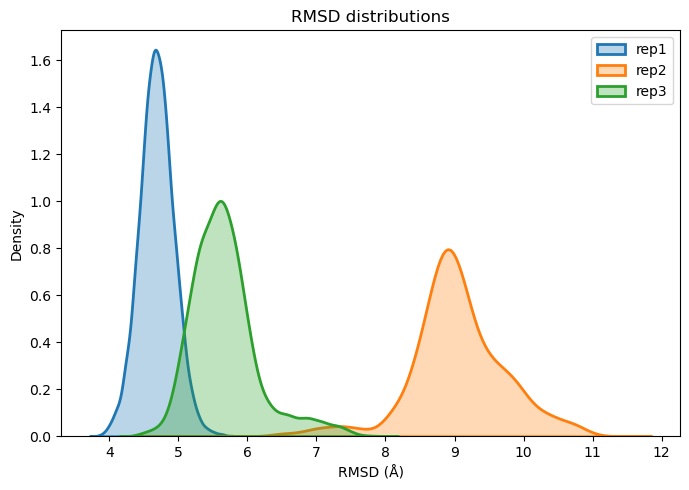

In [29]:
plt.figure(figsize=(7,5))

sns.kdeplot(rmsd_all_rep1, label="rep1", linewidth=2, fill=True, alpha=0.3)
sns.kdeplot(rmsd_all_rep2, label="rep2", linewidth=2, fill=True, alpha=0.3)
sns.kdeplot(rmsd_all_rep3, label="rep3", linewidth=2, fill=True, alpha=0.3)

plt.xlabel("RMSD (Å)")
plt.ylabel("Density")
plt.title("RMSD distributions")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

The ligand shows a high degree of freedom, and no stable orientation can be observed. In rep 1 it interacts with the receptor in a confromation which might be functional for the binding. In rep2 it doesn't interact with anything and stays in solution. This causes the C-terminal to start to unbound from the receptor as shown in the RMSD compared to the cryoEM strucutre. In rep3 it interacts with the membrane in a stable interaction over the simulation. Rep1 is the only one showing lower values for the RMSD of the bound stat of the C-terminal.   

### RL_complex core2

In [5]:
%cd /mnt/d/PhD/GPCR15/receptor/run1/rl_complex_core2

/mnt/d/PhD/GPCR15/receptor/run1/rl_complex_core2


In [7]:
!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/core2_RL_complex/md_mol.xtc .
!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/core2_RL_complex/md_extract.gro  .

md_mol.xtc                                    100%  427MB   5.8MB/s   01:13    
md_extract.gro                                100% 1738KB   2.4MB/s   00:00    


In [9]:
!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/core2_RL_complex/solv_ions.gro   .

solv_ions.gro                                 100% 7260KB   6.0MB/s   00:01    


### RL_complex core2 sia5

In [11]:
%cd /mnt/d/PhD/GPCR15/receptor/run1/rl_complex_core2_sia5

/mnt/d/PhD/GPCR15/receptor/run1/rl_complex_core2_sia5


In [12]:
!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/sia5_core2_RL_complex/md_mol.xtc .
!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/sia5_core2_RL_complex/md_extract.gro  .

md_mol.xtc                                    100%  419MB   5.8MB/s   01:12    
md_extract.gro                                100% 1753KB   2.3MB/s   00:00    


In [9]:
!scp nmrbox:/home/nmrbox/0030/dluciano/GPR15/gaston/Receptor/run1/core2_RL_complex/solv_ions.gro   .

solv_ions.gro                                 100% 7260KB   6.0MB/s   00:01    


## Complexes

### DP5

In [171]:
%cd /mnt/d/PhD/GPCR15/complexes/complex_polySia_DP5

/mnt/d/PhD/GPCR15/complexes/complex_polySia_DP5


In [172]:
#!scp -r triumvirate:/triumvirate/home/davidelu/GPR15L_simulations/complexes/complex_polySia_DP5/rep_* .

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [174]:
NR_REPS = 15
PATH = '/mnt/d/PhD/GPCR15/complexes/complex_polySia_DP5'

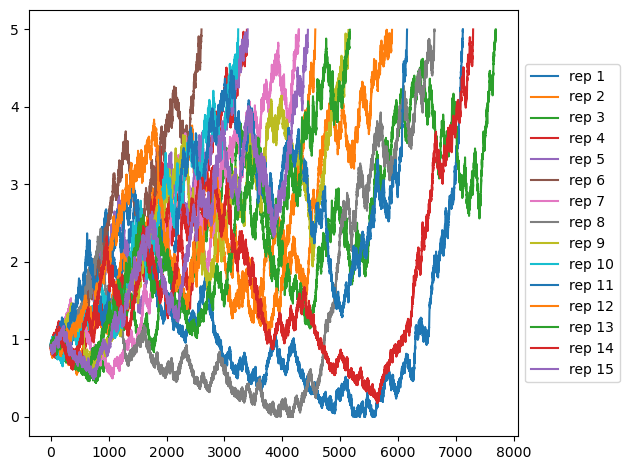

In [175]:
end_index_list = []
keep_list = []
for i in range(1,NR_REPS+1):
    filepath = f'{PATH}/rep_{i}/HILLS'

    if not os.path.exists(filepath):
        print(f'rep_{i} not found')
        continue
    data = np.loadtxt(filepath, skiprows=1, usecols=(0,1))

    
    # plot until y value of 7 and return x index
    try:
        end_index = np.where(data[:,1] > 5)[0][0]
        plt.plot(data[:,0][:end_index], data[:,1][:end_index], label=f'rep {i}')
        end_index_list.append(end_index)
        keep_list.append(i)
    except:
        print(f'rep_{i} did not unbind')

    #plt.plot(data[:,0][:10000], data[:,1][:10000], label=f'rep {i}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

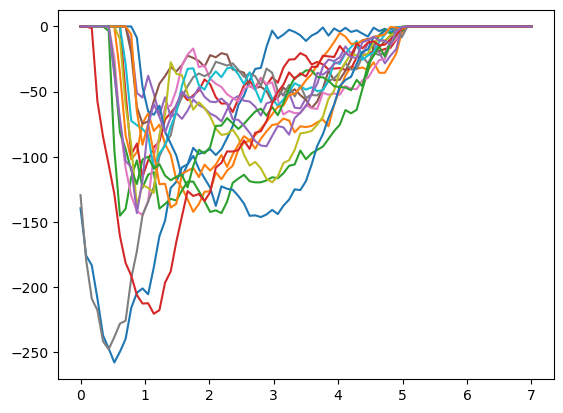

In [176]:
fes_list = []
for i,j in zip(keep_list, end_index_list):
    stride = j-1
    #!plumed sum_hills --hills {PATH}/rep_{i}/HILLS --outfile {PATH}/rep_{i}/fes_ --min 0 --max 7 --bin 80 --stride {stride}
    fespath = f'{PATH}/rep_{i}/fes_0.dat'
    #if not os.path.exists(fespath):
    #    fespath = f'{PATH}/rep_{i}/fes_'
    data = np.loadtxt(fespath, skiprows=1)
    plt.plot(data[:,0], data[:,1], label=f'rep {i}')
    fes_list.append(data)


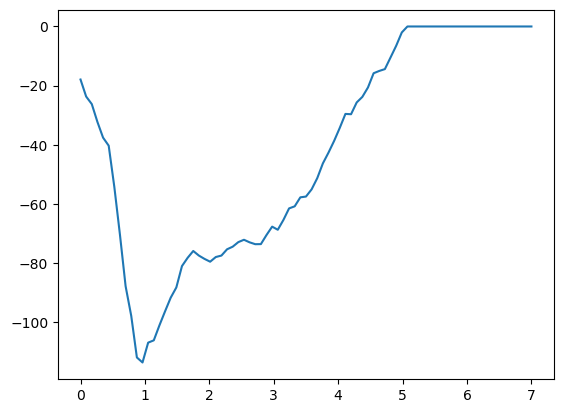

In [177]:
cv = fes_list[0][:,0]
fes_reps = np.array([fes[:,1] for fes in fes_list])
fes_avg = np.mean(fes_reps, axis=0)
fes_avg.shape
plt.plot(cv, fes_avg)
plt.savefig(f'{PATH}/FES.png', dpi=300)
plt.show()


In [178]:
fes_avg.argmin()

11

DFE -25.124934585542036


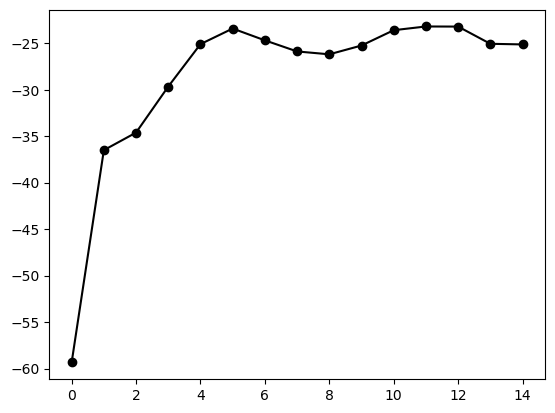

In [179]:

# this is to get the DFE for the averaged fes from all replicas 
T = 300.0
k = 0.008314462618 # kJ/mol
kBT = k*T
I = np.trapz(np.exp(-fes_avg / kBT), cv)
cv_0 = cv[fes_avg.argmin()]
cv_b = 5.2
L = cv_b - cv_0
Q = I / L 
DFE = -kBT*np.log(Q)/4.184

print('DFE',DFE)

# this is to assess the convergence 
nrep, npts = fes_reps.shape
DFE_seq = np.empty(nrep)
for r in range(1, nrep + 1):
    fes_avg_r = np.mean(fes_reps[:r], axis=0)
    I = np.trapz(np.exp(-fes_avg_r / kBT), cv)
    Q = I / L
    DFE_seq[r - 1] = -kBT * np.log(Q) / 4.184

plt.plot(range(nrep), DFE_seq, 'ko-')
plt.savefig(f'{PATH}/DFE.png', dpi=300)
plt.show()

In [108]:
np.average(DFE_seq[5:])

-24.559132384056937

In [109]:
np.std(DFE_seq[5:])

1.0673978938880953

In [190]:
# write a function to do DFE error estimate by bootstrapping 10 replicas, 1000 times
def bootstrap_DFE(fes_reps, nboot=1000, nselect=14):
    nrep, npts = fes_reps.shape
    DFE_boot = np.empty(nboot)
    for b in range(nboot):
        indices = np.random.choice(nrep, nselect, replace=True)
        fes_avg_b = np.mean(fes_reps[indices], axis=0)
        I = np.trapz(np.exp(-fes_avg_b / kBT), cv)
        Q = I / L
        DFE_boot[b] = -kBT * np.log(Q) / 4.184
    return np.mean(DFE_boot), np.std(DFE_boot)


In [191]:
result = bootstrap_DFE(fes_reps, nboot=1000, nselect=4)
with open(f'{PATH}/mean_std.txt', 'w') as f:
    f.write(f'{PATH}\n')
    f.write(f'{result}')

In [192]:
result

(-27.453368505968463, 5.473754596532141)

### DP10

In [158]:
%cd /mnt/d/PhD/GPCR15/complexes/complex_polySia_DP10

/mnt/d/PhD/GPCR15/complexes/complex_polySia_DP10


In [16]:
!scp -r triumvirate:/triumvirate/home/davidelu/GPR15L_simulations/complexes/complex_polySia_DP10/rep_* .

mdout.mdp                                     100%   10KB 277.9KB/s   00:00    
COLVAR                                        100%  491KB   3.4MB/s   00:00    
nvt.gro                                       100% 5541KB   7.4MB/s   00:00    
md_prev.cpt                                   100% 1929KB   2.8MB/s   00:00    
md.log                                        100% 6213KB  20.4MB/s   00:00    
npt.edr                                       100%   67KB 811.8KB/s   00:00    
md.cpt                                        100% 1929KB   3.7MB/s   00:00    
md.edr                                        100%   67KB   1.5MB/s   00:00    
md.xtc                                        100%   29MB   2.6MB/s   00:11    
nvt.edr                                       100%   30KB 651.9KB/s   00:00    
npt.gro                                       100% 5541KB   6.5MB/s   00:00    
md.tpr                                        100% 2325KB   3.5MB/s   00:00    
nvt_seeded.mdp                          

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [160]:
NR_REPS = 15
PATH = '/mnt/d/PhD/GPCR15/complexes/complex_polySia_DP10'

rep_1 did not unbind
rep_6 did not unbind
rep_11 did not unbind
rep_14 did not unbind


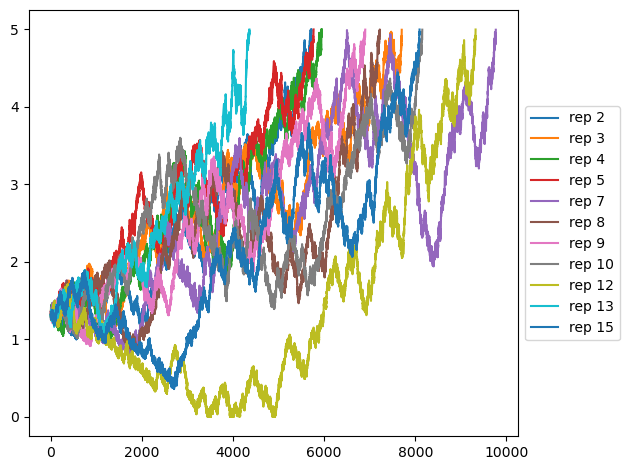

In [161]:
end_index_list = []
keep_list = []
for i in range(1,NR_REPS+1):
    filepath = f'{PATH}/rep_{i}/HILLS'

    if not os.path.exists(filepath):
        print(f'rep_{i} not found')
        continue
    data = np.loadtxt(filepath, skiprows=1, usecols=(0,1))

    
    # plot until y value of 7 and return x index
    try:
        end_index = np.where(data[:,1] > 5)[0][0]
        plt.plot(data[:,0][:end_index], data[:,1][:end_index], label=f'rep {i}')
        end_index_list.append(end_index)
        keep_list.append(i)
    except:
        print(f'rep_{i} did not unbind')

    #plt.plot(data[:,0][:10000], data[:,1][:10000], label=f'rep {i}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

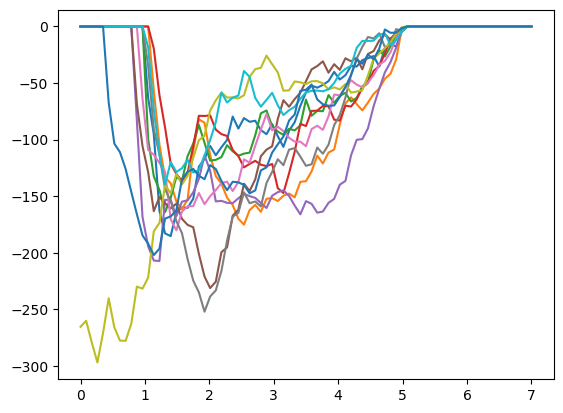

In [162]:
fes_list = []
for i,j in zip(keep_list, end_index_list):
    stride = j-1
    #!plumed sum_hills --hills {PATH}/rep_{i}/HILLS --outfile {PATH}/rep_{i}/fes_ --min 0 --max 7 --bin 80 --stride {stride}
    fespath = f'{PATH}/rep_{i}/fes_0.dat'
    #if not os.path.exists(fespath):
    #    fespath = f'{PATH}/rep_{i}/fes_'
    data = np.loadtxt(fespath, skiprows=1)
    plt.plot(data[:,0], data[:,1], label=f'rep {i}')
    fes_list.append(data)


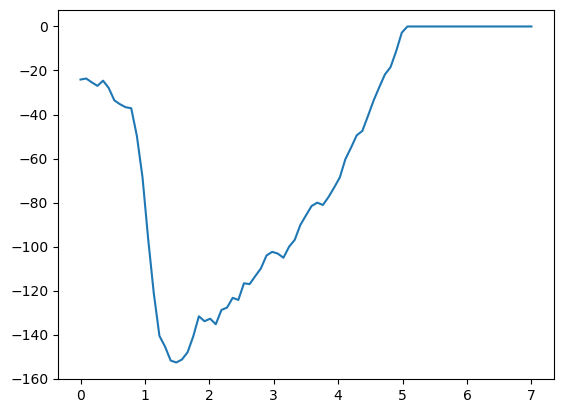

In [163]:
cv = fes_list[0][:,0]
fes_reps = np.array([fes[:,1] for fes in fes_list])
fes_avg = np.mean(fes_reps, axis=0)
fes_avg.shape
plt.plot(cv, fes_avg)
plt.savefig(f'{PATH}/FES.png', dpi=300)
plt.show()


In [164]:
fes_avg.argmin()

17

DFE -34.806357941957046


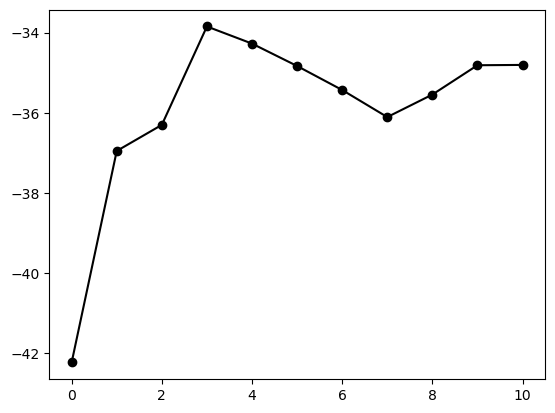

In [165]:

# this is to get the DFE for the averaged fes from all replicas 
T = 300.0
k = 0.008314462618 # kJ/mol
kBT = k*T
I = np.trapz(np.exp(-fes_avg / kBT), cv)
cv_0 = cv[fes_avg.argmin()]
cv_b = 5.2
L = cv_b - cv_0
Q = I / L 
DFE = -kBT*np.log(Q)/4.184

print('DFE',DFE)

# this is to assess the convergence 
nrep, npts = fes_reps.shape
DFE_seq = np.empty(nrep)
for r in range(1, nrep + 1):
    fes_avg_r = np.mean(fes_reps[:r], axis=0)
    I = np.trapz(np.exp(-fes_avg_r / kBT), cv)
    Q = I / L
    DFE_seq[r - 1] = -kBT * np.log(Q) / 4.184

plt.plot(range(nrep), DFE_seq, 'ko-')
plt.savefig(f'{PATH}/DFE.png', dpi=300)
plt.show()

In [166]:
np.average(DFE_seq[5:])

-35.256362612674415

In [167]:
np.std(DFE_seq[5:])

0.48553883816600796

In [168]:
# write a function to do DFE error estimate by bootstrapping 10 replicas, 1000 times
def bootstrap_DFE(fes_reps, nboot=1000, nselect=10):
    nrep, npts = fes_reps.shape
    DFE_boot = np.empty(nboot)
    for b in range(nboot):
        indices = np.random.choice(nrep, nselect, replace=True)
        fes_avg_b = np.mean(fes_reps[indices], axis=0)
        I = np.trapz(np.exp(-fes_avg_b / kBT), cv)
        Q = I / L
        DFE_boot[b] = -kBT * np.log(Q) / 4.184
    return np.mean(DFE_boot), np.std(DFE_boot)


In [169]:
result = bootstrap_DFE(fes_reps, nboot=1000, nselect=4)
with open(f'{PATH}/mean_std.txt', 'w') as f:
    f.write(f'{PATH}\n')
    f.write(f'{result}')

In [170]:
result

(-37.033869442869474, 3.4957496137904265)

### DP20

In [138]:
%cd /mnt/d/PhD/GPCR15/complexes/complex_polySia_DP20

/mnt/d/PhD/GPCR15/complexes/complex_polySia_DP20


In [30]:
!scp -r triumvirate:/triumvirate/home/davidelu/GPR15L_simulations/complexes/complex_polySia_DP20/rep_* .

mdout.mdp                                     100%   10KB 318.5KB/s   00:00    
COLVAR                                        100%  492KB   3.4MB/s   00:00    
nvt.gro                                       100% 8752KB  11.6MB/s   00:00    
md_prev.cpt                                   100% 3047KB   5.2MB/s   00:00    
md.log                                        100% 6218KB  21.9MB/s   00:00    
npt.edr                                       100%   67KB   1.6MB/s   00:00    
md.cpt                                        100% 3047KB   5.5MB/s   00:00    
md.edr                                        100%   67KB   1.1MB/s   00:00    
md.xtc                                        100%   46MB   5.6MB/s   00:08    
nvt.edr                                       100%   30KB 609.3KB/s   00:00    
npt.gro                                       100% 8752KB  11.9MB/s   00:00    
md.tpr                                        100% 3572KB   5.4MB/s   00:00    
nvt_seeded.mdp                          

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [140]:
NR_REPS = 22
PATH = '/mnt/d/PhD/GPCR15/complexes/complex_polySia_DP20'

rep_1 did not unbind
rep_7 did not unbind
rep_8 did not unbind
rep_14 did not unbind
rep_16 did not unbind
rep_18 did not unbind
rep_19 did not unbind
rep_20 did not unbind
rep_22 did not unbind


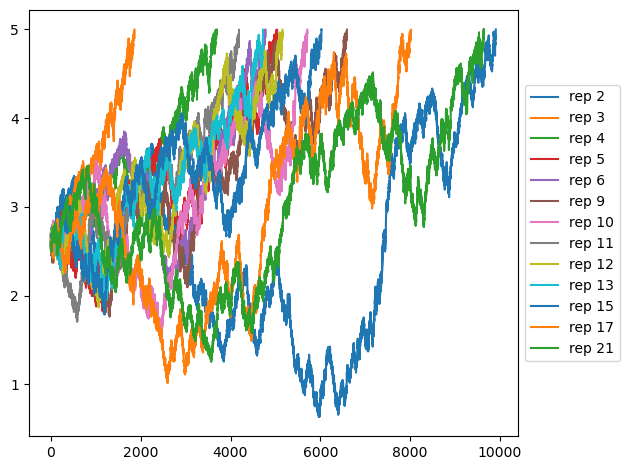

In [141]:
end_index_list = []
keep_list = []
for i in range(1,NR_REPS+1):
    filepath = f'{PATH}/rep_{i}/HILLS'

    if not os.path.exists(filepath):
        print(f'rep_{i} not found')
        continue
    data = np.loadtxt(filepath, skiprows=1, usecols=(0,1))

    
    # plot until y value of 7 and return x index
    try:
        end_index = np.where(data[:,1] > 5)[0][0]
        plt.plot(data[:,0][:end_index], data[:,1][:end_index], label=f'rep {i}')
        end_index_list.append(end_index)
        keep_list.append(i)
    except:
        print(f'rep_{i} did not unbind')

    #plt.plot(data[:,0][:10000], data[:,1][:10000], label=f'rep {i}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

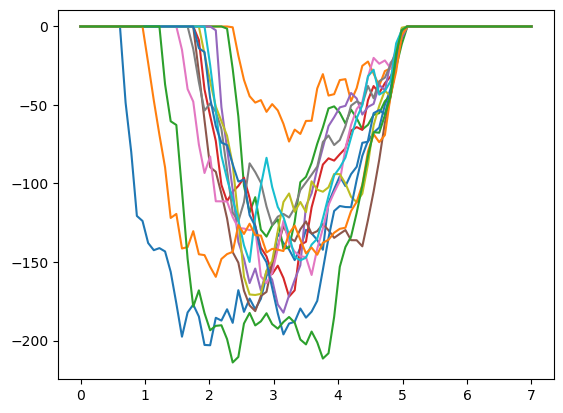

In [142]:
fes_list = []
for i,j in zip(keep_list, end_index_list):
    stride = j-1
    #!plumed sum_hills --hills {PATH}/rep_{i}/HILLS --outfile {PATH}/rep_{i}/fes_ --min 0 --max 7 --bin 80 --stride {stride}
    fespath = f'{PATH}/rep_{i}/fes_0.dat'
    #if not os.path.exists(fespath):
    #    fespath = f'{PATH}/rep_{i}/fes_'
    data = np.loadtxt(fespath, skiprows=1)
    plt.plot(data[:,0], data[:,1], label=f'rep {i}')
    fes_list.append(data)


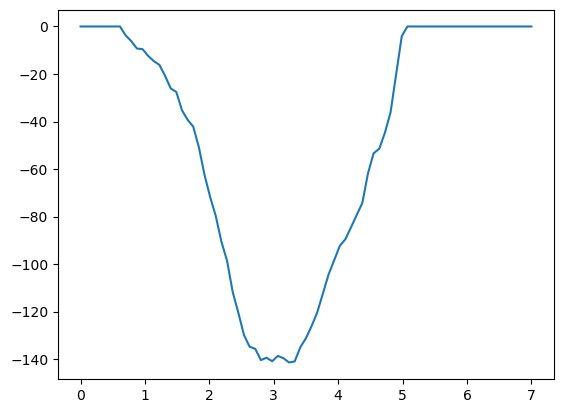

In [143]:
cv = fes_list[0][:,0]
fes_reps = np.array([fes[:,1] for fes in fes_list])
fes_avg = np.mean(fes_reps, axis=0)
fes_avg.shape
plt.plot(cv, fes_avg)
plt.savefig(f'{PATH}/FES.png', dpi=300)
plt.show()


In [144]:
fes_avg.argmin()

37

DFE -32.88572575698184


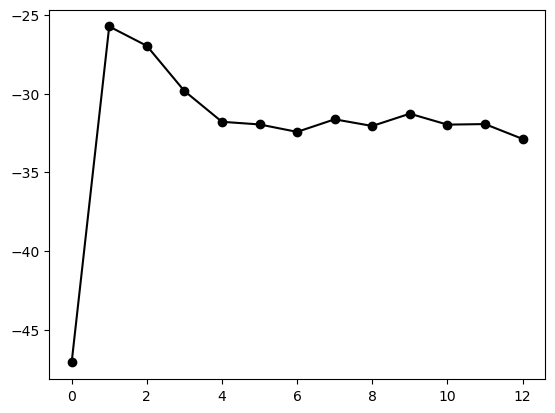

In [145]:

# this is to get the DFE for the averaged fes from all replicas 
T = 300.0
k = 0.008314462618 # kJ/mol
kBT = k*T
I = np.trapz(np.exp(-fes_avg / kBT), cv)
cv_0 = cv[fes_avg.argmin()]
cv_b = 5.2
L = cv_b - cv_0
Q = I / L 
DFE = -kBT*np.log(Q)/4.184

print('DFE',DFE)

# this is to assess the convergence 
nrep, npts = fes_reps.shape
DFE_seq = np.empty(nrep)
for r in range(1, nrep + 1):
    fes_avg_r = np.mean(fes_reps[:r], axis=0)
    I = np.trapz(np.exp(-fes_avg_r / kBT), cv)
    Q = I / L
    DFE_seq[r - 1] = -kBT * np.log(Q) / 4.184

plt.plot(range(nrep), DFE_seq, 'ko-')
plt.savefig(f'{PATH}/DFE.png', dpi=300)
plt.show()

In [146]:
np.average(DFE_seq[4:])

-31.99966343374728

In [147]:
np.std(DFE_seq[4:])

0.4306996838412388

In [153]:
# write a function to do DFE error estimate by bootstrapping 10 replicas, 1000 times
def bootstrap_DFE(fes_reps, nboot=1000, nselect=12):
    nrep, npts = fes_reps.shape
    DFE_boot = np.empty(nboot)
    for b in range(nboot):
        indices = np.random.choice(nrep, nselect, replace=True)
        fes_avg_b = np.mean(fes_reps[indices], axis=0)
        I = np.trapz(np.exp(-fes_avg_b / kBT), cv)
        Q = I / L
        DFE_boot[b] = -kBT * np.log(Q) / 4.184
    return np.mean(DFE_boot), np.std(DFE_boot)


In [156]:
result = bootstrap_DFE(fes_reps, nboot=1000, nselect=4)
with open(f'{PATH}/mean_std.txt', 'w') as f:
    f.write(f'{PATH}\n')
    f.write(f'{result}')

In [157]:
result

(-34.52214551435204, 3.543028325438672)

#### All together

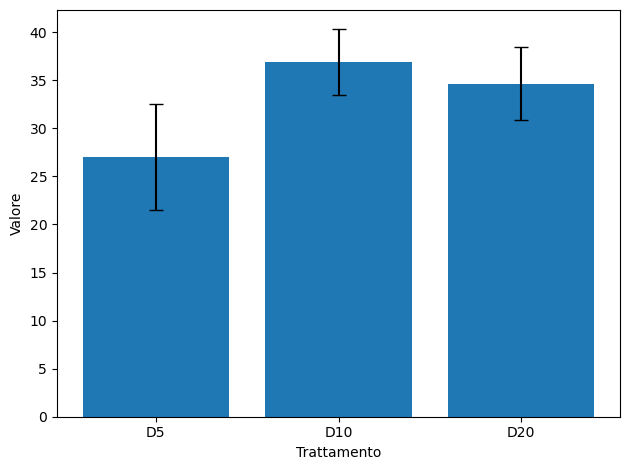

In [67]:
import numpy as np
import matplotlib.pyplot as plt


labels = ['D5', 'D10', 'D20']


means = [27, 36.9, 34.66]


stds = [5.5, 3.4, 3.8]

x = np.arange(len(labels))

plt.figure()
plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, labels)
plt.ylabel('Valore')
plt.xlabel('Trattamento')

plt.tight_layout()
plt.show()

Increasing the sialic acid units seems to have an effect, howevre, the D10 might not be converged like the other two. 

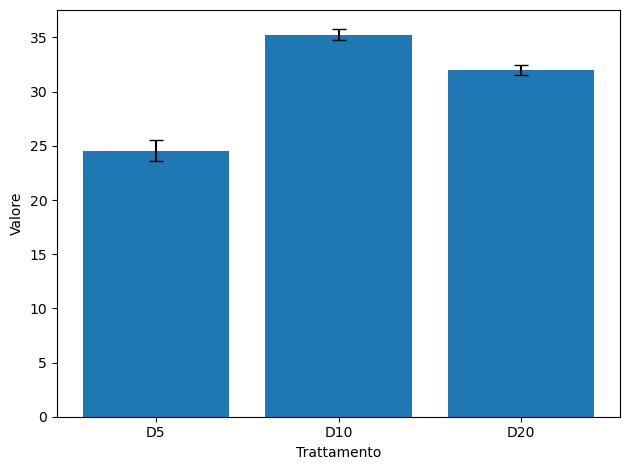

In [193]:
import numpy as np
import matplotlib.pyplot as plt


labels = ['D5', 'D10', 'D20']


means = [24.56, 35.26, 32.0]


stds = [1.0, 0.49, 0.43]

x = np.arange(len(labels))

plt.figure()
plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, labels)
plt.ylabel('Valore')
plt.xlabel('Trattamento')

plt.tight_layout()
plt.show()

This is how it looks if we consider the variation of the convergend part of the DFE value. it is an estimate of which number i would get if i run another replica to add in the average. 

In conclusion the polysialic part interacts with the same residues that have shown an interaction in the free receptor (R19 R34). IF we assume a the standard two steps model for the chemockine binding path also  for this ligand, this might sugget that the glycosilation can shield this site avoidning the proper orientation of the ligand in the binding site.  Incrasing the glycosilation doesn't change the effect since it becomes longer then the ligand. 

Thing that might be important to test: 

- Preparing the system with the ligand in the stable conformaiton of rep1 but with the C-term not bound to see if it binds + replica
- testing how the dynamics of the bound ligand changes in the presence of the same glycosiltations as the DFE
- The DFE has been computed starting from different binding modes of the glycan to the ligand. Mybe it would be better to start from the same type of interaction maybe sampled in the receptor simulation. 